In [4047]:
import numpy as np
import pandas as pd
import yaml
import os
from matplotlib import pyplot as plt
from hsa_hopper.kinematics import KinematicParameters
from hsa_hopper.controller import HopController
from hsa_hopper.hsa_model import HSAModel

kin_params = KinematicParameters(.07,.15,.3,-.005)
actuator_model_path = r'C:\Users\Joseph\OneDrive - UW\code\hsa_hopper_control\notebooks\actuator_model.yaml'
with open(actuator_model_path, 'r') as f:
    actuator_model = yaml.load(f, yaml.Loader)

def load_data(path):
    dataframes = {}
    hardware_configs = {}
    controller_params = {}
    optimized = True
    if 'unoptimized' in path:
        optimized = False
    for category in os.listdir(path):
        hsa = True
        if 'no_hsa' in category:
            hsa = False
        if os.path.isfile(category):
            continue
        dataframes[category] = {}
        hardware_configs[category] = {}
        controller_params[category] = {}
        category_folder = os.path.join(path,category)
        total_mass = int(category.split('_')[-1][:-1])/1000
        for trial in os.listdir(category_folder):
            trial_folder = os.path.join(category_folder, trial)
            # load config files
            with open(os.path.join(trial_folder,'hardware_config.yaml')) as f:
                hardware_configs[category][trial] = yaml.load(f,yaml.Loader)
            with open(os.path.join(trial_folder,'experiment_config.yaml')) as f:
                experiment_config = yaml.load(f,yaml.Loader)
                controller_params[category][trial] = experiment_config['controller']
            # load (smoothed) data files
            trial_df = pd.read_csv(os.path.join(trial_folder,'data.csv'))
            trial_df['total_mass'] = total_mass
            trial_df['optimized'] = optimized
            trial_df['hsa'] = hsa
            trial_df['psi'] = (experiment_config['controller']['servo_pos']-1500)*(np.pi/4/200)
            trial_df['mask'] = np.zeros(len(trial_df),dtype=bool)
            # chop-off the end of stance and the end of flight phases
            flight_drop_count = 20
            stance_drop_count = 10
            min_stance_duration = 10
            row_offset = 0
            col_map = {col: i for i,col in enumerate(trial_df.columns)}
            for hop_idx in trial_df['hop_idx'].unique():
                try:
                    hop_start = next(i for i in range(row_offset,len(trial_df)) if trial_df['hop_idx'][i] == hop_idx)
                    hop_end = next(i for i in range(hop_start,len(trial_df)) if trial_df['hop_idx'][i] != hop_idx)
                    row_offset = hop_end
                except:
                    print(f"final hop at index {hop_idx} of trial {trial} in category {category} is incomplete. Dropping!")
                    trial_df.iloc[hop_start:hop_end,col_map['mask']] = True
                    break
                try:
                    flight_start = next(i for i in range(hop_start,len(trial_df)) if trial_df['mode'][i] == HopController._FLIGHT)
                    if flight_start-hop_start < min_stance_duration:
                        # the control mode is likely chattering, so drop the hop
                        trial_df.iloc[hop_start:hop_end,col_map['mask']] = True
                        print(f'dropping {range(hop_start,hop_end)} from hop {hop_idx} of trial {trial} in category {category}')
                    else:
                        # trim the stance mode
                        trial_df.iloc[hop_start:hop_start+stance_drop_count,col_map['mask']] = True
                        trial_df.iloc[flight_start-stance_drop_count:flight_start,col_map['mask']] = True
                        # trim the flight mode
                        trial_df.iloc[hop_end-flight_drop_count:hop_end,col_map['mask']] = True

                except: # no flight period, drop the hop
                    trial_df.iloc[hop_start:hop_end,col_map['mask']] = True
                    continue
            dataframes[category][trial] = trial_df
    return dataframes, hardware_configs, controller_params


# char_model_path = r'/home/joseph/workspaces/hsa_hopper/hsa_hopper_control/notebooks/hsa_model.yaml'

In [4048]:
# configure matplotlib rcparams for style
import matplotlib.pyplot as plt
from cycler import cycler

# Set the font to Times New Roman
plt.rcParams['font.family'] = 'Times New Roman'

# Define a custom color cycle of 10 colors
colorblind_friendly_colors = ['#6a0dad', '#2ca02c', '#e2a000', '#1f77b4', '#ff7f0e', '#d62728']

# Update the default color cycler
plt.rcParams['axes.prop_cycle'] = cycler(color=colorblind_friendly_colors)

In [4049]:
unoptimized_path = r'C:\Users\Joseph\OneDrive - UW\code\hsa_hopper_control\data\aim2\4_28\unoptimized'
optimized_path = r'C:\Users\Joseph\OneDrive - UW\code\hsa_hopper_control\data\aim2\4_28\optimized'

# load data into dictionaries
unoptimized_data = load_data(unoptimized_path)
optimized_data = load_data(optimized_path)

# combine hopping data into a giant dataframe
hop_dfs = []
for condition, trials in unoptimized_data[0].items():
    for trial, df in trials.items():
        hop_dfs.append(df)
for condition, trials in optimized_data[0].items():
    for trial, df in trials.items():
        hop_dfs.append(df)
MASTER_DF = pd.concat(hop_dfs)
test_mask = (MASTER_DF['hsa'] == True) & (MASTER_DF['optimized'] == True)
MODEL_TEST_DF = MASTER_DF.loc[test_mask,:]

final hop at index 83 of trial hsa_1700g_53mm_avg in category hsa_1700g is incomplete. Dropping!
final hop at index 69 of trial no_hsa_1700g_52mm_avg in category no_hsa_1700g is incomplete. Dropping!
final hop at index 50 of trial 0deg in category hsa_1700g is incomplete. Dropping!
final hop at index 51 of trial 22deg in category hsa_1700g is incomplete. Dropping!
final hop at index 51 of trial 45deg in category hsa_1700g is incomplete. Dropping!
final hop at index 66 of trial 2025-04-14_1744652480 in category no_hsa_1700g is incomplete. Dropping!


In [4050]:
from hsa_hopper.hsa_model import HSAModel
from hsa_hopper.controller import HopController
def make_lstsq_data(model: HSAModel, actuator_model: dict, frame: pd.DataFrame):
    N = model.num_params()
    M = len(frame)
    A = np.zeros((M,N))
    b = np.zeros(M)
    l = frame['l_m'].to_numpy()
    xdot = frame['xdot'].to_numpy()
    ldot = frame['ldot'].to_numpy()
    ydot = frame['ydot'].to_numpy()
    xddot = frame['xddot'].to_numpy()
    lddot = frame['lddot'].to_numpy()
    yddot = frame['yddot'].to_numpy()
    tau = frame['torque'].to_numpy()
    dldx = frame['dldx'].to_numpy()
    dydx = frame['dydx'].to_numpy()
    psi = frame['psi'].to_numpy()
    mode = frame['mode'].to_numpy()
    mask = frame['mask'].to_numpy()
    total_mass = frame['total_mass'].to_numpy()

    stance_mdot = (dydx*yddot)
    flight_mdot = (dldx*lddot)
    stance_grav = (dydx*9.81)
    flight_grav = (dldx*9.81)
    m_cart = total_mass - actuator_model['m_foot']
    m_foot = actuator_model['m_foot']
    b[:] = tau[:]
    b -= m_cart*(mode == HopController._STANCE)*(stance_grav+stance_mdot)
    b -= m_foot*(mode == HopController._FLIGHT)*(flight_grav+flight_mdot)
    b -= actuator_model['J']*xddot
    b -= actuator_model['bx']*xdot

    A[:,0] = dldx*l # HSA linear spring constant (K) column
    A[:,1] = dldx   # HSA linear spring offset (F0) column
    A[:,2] = dldx*ldot   # HSA linear damping coefficient (bl) column

    # Nonlinear spring and damper parameters
    if model.y is not None:
        ks, kd, dks, dkd = model.covectors(l, ldot, psi, grad=True)
        offset = 3
        if ks is not None:
            for i in range(ks.shape[0]):
                A[:,offset+i] = dks[i,:]*dldx
            offset += ks.shape[0]
        if kd is not None:
            for i in range(kd.shape[0]):
                A[:,offset+i] = dkd[i,:]*dldx
    # overwite masked rows with zero, eliminating them from the least squares problem
    A[mask,:] = 0
    b[mask] = 0
    return A,b

In [4051]:
def make_weight_regularizer(hsa_model: HSAModel, frame: pd.DataFrame):
    l = frame['l_m'].to_numpy()
    ldot = frame['ldot'].to_numpy()
    psi = frame['psi'].to_numpy()
    dldx = frame['dldx'].to_numpy()
    num_params = hsa_model.num_params()
    A = np.zeros((len(frame), num_params))
    if hsa_model.y is not None:
        kc, kd, dkc, dkd = hsa_model.covectors(l,ldot,psi,grad=True)
        num_params = hsa_model.num_params()
        offset = 3
        if hsa_model.w_c is not None:
            for i in range(hsa_model.w_c.size):
                A[:,offset+i] = (dkc[i,:]*dldx)
            offset += hsa_model.w_c.size
        if hsa_model.w_d is not None:
            for i in range(hsa_model.w_d.size):
                A[:,offset+i] = (dkd[i,:]*dldx)
    return A

In [4052]:
"""
Experimental - fitting two potential functions and blending them together with a logistic function
"""

from scipy.optimize import minimize
from scipy.optimize import LinearConstraint
from hsa_hopper.hsa_model import HSAModel 

# function to do the model optimization
def governing_equation_lstsq(hsa_model, actuator_model, reg_penalty, frame: pd.DataFrame, optimize=True, include_linear_terms=True):
    N = hsa_model.num_params()
    A,b = make_lstsq_data(hsa_model,actuator_model,frame)
    B = make_weight_regularizer(hsa_model,frame)
    # rescaling A matrix for better conditioning of constraint evaluation
    SCALE = np.ones(A.shape[1])
    SCALE[0] = 1 # linear spring constant rescaling
    SCALE[1] = 1 # linear force rescaling
    SCALE[2] = 1 # linear damping rescaling

    A_scaled = A*SCALE
    B_scaled = B*SCALE
    ATA = A_scaled.T@A_scaled
    BTB = B_scaled.T@B_scaled
    ATb = A_scaled.T@b
    bTb = np.dot(b,b)
    f = lambda x: x.T@(ATA+reg_penalty*BTB)@x+bTb-2*x.T@ATb
    jac = lambda x: 2*(ATA+reg_penalty*BTB)@x-2*ATb

    x0 = np.zeros(N)
    x0[0] = hsa_model.K
    x0[1] = hsa_model.F0
    x0[2] = hsa_model.b
    offset = 3
    if hsa_model.w_c is not None:
        x0[offset:offset+hsa_model.w_c.size] = hsa_model.w_c
        offset += hsa_model.w_c.size
    if hsa_model.w_d is not None:
        x0[offset:] = hsa_model.w_d

    if not optimize:
        errors = (A_scaled@x0-b)
        sos_res = np.sum(errors**2)
        r_sqr = 1-sos_res/np.sum((b-np.average(b))**2)
        errors = A@(SCALE*x0)-b
        result = {
            'r_sqr' : r_sqr,
            'errors' : errors,
            'b' : b
        }
        return result
    else:
        # rescaling matrix for parameters, useful for conditioning
        # the constraint evaluations

        # next constraints - enforce positive weights
        # and positive definiteness of stiffness/damping at basis centers
        C = np.eye(N)
        if include_linear_terms:
            lb = np.array([0,-1000,0])
            ub = np.array([1000,1000,100])
        else:
            lb = np.array([hsa_model.K, hsa_model.F0, hsa_model.b])
            ub = np.array([hsa_model.K, hsa_model.F0, hsa_model.b])
        if hsa_model.w_c is not None:
            lb = np.hstack((lb, -1e3*np.ones(hsa_model.w_c.size)))
            ub = np.hstack((ub, 0*np.ones(hsa_model.w_c.size)))
        if hsa_model.w_d is not None:
            lb = np.hstack((lb, 0*np.ones(hsa_model.w_d.size)))
            ub = np.hstack((ub, 1e3*np.ones(hsa_model.w_d.size)))

        constraints = [LinearConstraint(C,lb=lb,ub=ub)]

        x0 = np.zeros(N)
        result = minimize(f, x0, 
                        jac=jac, 
                        constraints=constraints, 
                        method='SLSQP',
                        options={'maxiter' : 12000, 'ftol': 1e-12}
        )
        result.A = A
        result.b = b
        result.sample_size = b.shape[0]
        result.num_params = hsa_model.num_params()
        hsa_model.K = result.x[0]*SCALE[0]
        hsa_model.F0 = result.x[1]*SCALE[1]
        hsa_model.b = result.x[2]*SCALE[2]
        offset = 3
        if hsa_model.w_c is not None:
            hsa_model.w_c = result.x[offset:offset+hsa_model.w_c.size]
            offset += hsa_model.w_c.size
        if hsa_model.w_d is not None:
            hsa_model.w_d = result.x[offset:offset+hsa_model.w_d.size]
        result.model = hsa_model
        result.errors = (A_scaled@result.x-b)
        result.sos_errors = np.sum(result.errors**2)
        result.r_sqr = 1-result.sos_errors/np.sum((b-np.average(b))**2)
        result.r_sqr_adj = 1-(1-result.r_sqr)*(result.sample_size-1)/(result.sample_size-result.num_params-1)
        result.mse = result.sos_errors/result.sample_size
        result.rmse = np.sqrt(result.mse)
        result.bic = result.sample_size*np.log(result.mse)+result.num_params*np.log(result.sample_size)
        result.errors = A@(SCALE*result.x)-b
        return result 
    

In [4053]:
nlsd_char_path = r'C:\Users\Joseph\OneDrive - UW\code\hsa_hopper_control\data\aim2\4_28\hsa_identification\all_together\nlsd_model.yaml'
with open(nlsd_char_path,'r') as f:
    attrs = yaml.load(f,yaml.Loader)
    nlsd_char_model = HSAModel.make_from_dict(attrs)
nlsd_char_result =  governing_equation_lstsq(nlsd_char_model, actuator_model, 0, MODEL_TEST_DF, optimize=False)
print(nlsd_char_result)

{'r_sqr': np.float64(0.9204493703707373), 'errors': array([0.        , 0.        , 0.        , ..., 1.77550777, 1.70776529,
       1.67499503], shape=(39946,)), 'b': array([ 0.        ,  0.        ,  0.        , ..., -1.5264196 ,
       -1.44598664, -1.40042209], shape=(39946,))}


In [4054]:

nls_char_path = r'C:\Users\Joseph\OneDrive - UW\code\hsa_hopper_control\data\aim2\4_28\hsa_identification\all_together\nls_model.yaml'
with open(nls_char_path,'r') as f:
    attrs = yaml.load(f,yaml.Loader)
    nls_char_model = HSAModel.make_from_dict(attrs)
nls_char_result =  governing_equation_lstsq(nls_char_model, actuator_model, 0, MODEL_TEST_DF, optimize=False)
print(nls_char_result)

{'r_sqr': np.float64(0.9233101680162653), 'errors': array([0.        , 0.        , 0.        , ..., 1.86257167, 1.7944521 ,
       1.76113842], shape=(39946,)), 'b': array([ 0.        ,  0.        ,  0.        , ..., -1.5264196 ,
       -1.44598664, -1.40042209], shape=(39946,))}


In [4055]:
linear_model_path = r'C:\Users\Joseph\OneDrive - UW\code\hsa_hopper_control\data\aim2\4_28\hsa_identification\all_together\linear_model.yaml'
with open(linear_model_path,'r') as f:
    attrs = yaml.load(f,yaml.Loader)
    linear_model = HSAModel.make_from_dict(attrs)
linear_char_result =  governing_equation_lstsq(linear_model, actuator_model, 0, MODEL_TEST_DF, optimize=False)
print(linear_char_result)

{'r_sqr': np.float64(0.8962563253451763), 'errors': array([0.        , 0.        , 0.        , ..., 2.0196369 , 1.95561942,
       1.92653427], shape=(39946,)), 'b': array([ 0.        ,  0.        ,  0.        , ..., -1.5264196 ,
       -1.44598664, -1.40042209], shape=(39946,))}


In [4056]:
nld_char_path = r'C:\Users\Joseph\OneDrive - UW\code\hsa_hopper_control\data\aim2\4_28\hsa_identification\all_together\nld_model.yaml'
with open(nld_char_path,'r') as f:
    attrs = yaml.load(f,yaml.Loader)
    nld_char_model = HSAModel.make_from_dict(attrs)
nld_char_result =  governing_equation_lstsq(nld_char_model, actuator_model, 0, MODEL_TEST_DF, optimize=False)
print(nld_char_result)

{'r_sqr': np.float64(0.8989467346952214), 'errors': array([0.        , 0.        , 0.        , ..., 2.02859707, 1.96489945,
       1.93613   ], shape=(39946,)), 'b': array([ 0.        ,  0.        ,  0.        , ..., -1.5264196 ,
       -1.44598664, -1.40042209], shape=(39946,))}


In [4057]:
from copy import deepcopy
# char_model_path = r'C:\Users\Joseph Sullivan\Documents\hsa_hopper_control\data\aim2\4_30\hsa_identification\all_data\linear_model_30deg.yaml'
linear_models = [
    r'C:\Users\Joseph\OneDrive - UW\code\hsa_hopper_control\data\aim2\4_28\hsa_identification\all_together\linear_model_0deg.yaml',
    r'C:\Users\Joseph\OneDrive - UW\code\hsa_hopper_control\data\aim2\4_28\hsa_identification\all_together\linear_model_22deg.yaml',
    r'C:\Users\Joseph\OneDrive - UW\code\hsa_hopper_control\data\aim2\4_28\hsa_identification\all_together\linear_model_45deg.yaml',
    r'C:\Users\Joseph\OneDrive - UW\code\hsa_hopper_control\data\aim2\4_28\hsa_identification\all_together\linear_model_67deg.yaml',
]
all_errors = []
all_b = []
for i,psi in enumerate(MASTER_DF['psi'].unique()):
    print((i,psi))
    with open(linear_models[i], 'r') as f:
        hsa_char_model = HSAModel.make_from_dict(yaml.load(f, yaml.Loader))
    frame = MODEL_TEST_DF['psi'] == psi
    result = governing_equation_lstsq(hsa_char_model, actuator_model, 0, MODEL_TEST_DF.loc[frame,:], optimize=False)
    print(result['r_sqr'])
    all_errors.append(result['errors'])
    all_b.append(result['b'])
errors = np.hstack(all_errors)
b = np.hstack(all_b)
sos_res = np.sum(errors**2)
print(errors.size)
sos_tot = np.sum((b-np.average(b))**2)
mse = sos_res / b.size
rmse = np.sqrt(mse)
r_sqr = 1-sos_res/sos_tot

ml_char_result = {'r_sqr' : r_sqr, 'errors': errors, 'b' : b}
print(f'Multiple Linear Models RMSE: {rmse}')
print(f'Multiple Linear Models R^2: {r_sqr}')


(0, np.float64(0.7853981633974484))
0.836232279865683
(1, np.float64(0.0))
0.9112812719865052
(2, np.float64(0.3926990816987242))
0.9039423121525433
39946
Multiple Linear Models RMSE: 0.409782253753214
Multiple Linear Models R^2: 0.8835695426621869


In [4058]:
from scipy.stats import normaltest
from scipy.stats import t as tdist

def different_means_pvalue(x,y):
    nx = x.size
    ny = y.size
    sx = np.std(x)
    sy = np.std(y)
    mx = np.average(x)
    my = np.average(y)
    df = ((sx**2/nx)+(sy**2/ny))**2/((sx**2/nx)**2/(nx-1)+(sy**2/ny)**2/(ny-1))
    serr = np.sqrt(sx**2/nx+sy**2/ny)
    if mx > my:
        t_score = (mx-my)/serr
    else:
        t_score = (my-mx)/serr
    return tdist.cdf(-t_score,df) + tdist.sf(t_score,df)

In [4059]:
# compare nonlinear spring to nonlinear spring-damper model
x = nlsd_char_result['errors']
y = nls_char_result['errors']
different_means_pvalue(x**2,y**2)

np.float64(0.2039430880659398)

In [4060]:
# compare nonlinear damping to linear model 
x = linear_char_result['errors']
y = nld_char_result['errors']
different_means_pvalue(x**2,y**2)

np.float64(0.21816556255641678)

In [4061]:
unique_psi = MODEL_TEST_DF['psi'].unique()
N_l_basis = 4
N_psi_basis = 2
lmin = MODEL_TEST_DF['l_m'].min()
lmax = MODEL_TEST_DF['l_m'].max()
psi_min = MODEL_TEST_DF['psi'].min()
psi_max = MODEL_TEST_DF['psi'].max()
# lvec = (lmax+lmin)/2 + (lmax-lmin)/2*np.cos(np.linspace(-np.pi,0,N_l_basis))
lvec = np.linspace(lmin,lmax,N_l_basis) 
# psivec = (psi_max+psi_min)/2 + (psi_max-psi_min)/2*np.cos(np.linspace(-np.pi,0,N_psi_basis))
psivec = np.linspace(psi_min,psi_max,N_psi_basis)
y = np.zeros((N_psi_basis*N_l_basis,2))
for i in range(psivec.size):
    y[i*N_l_basis:(i+1)*N_l_basis,0] = lvec
    y[i*N_l_basis:(i+1)*N_l_basis,1] = psivec[i]
S = np.cov(y, rowvar=False)
S = np.linalg.inv(S)
a = 1
s = 1
nls_model = HSAModel(0,0,0,y,S,np.zeros(y.shape[0]),None,a,s)
nls_result = governing_equation_lstsq(nls_model,actuator_model,0.,MODEL_TEST_DF)
print(nls_result)

     message: Optimization terminated successfully
     success: True
      status: 0
         fun: 2763.5931037209957
           x: [ 8.353e+02 -1.040e+02  1.312e+01 -3.233e-01  3.499e-16
               -2.946e-01 -3.914e-01  3.734e-16  4.090e-16 -6.056e-02
               -5.081e-01]
         nit: 27
         jac: [ 4.673e-06  4.443e-05 -1.496e-05 -1.002e-03 -1.457e+01
                6.571e-04  6.555e-04 -3.329e+01 -1.789e+02 -1.600e-05
               -7.941e-05]
        nfev: 81
        njev: 27
           A: [[ 0.000e+00  0.000e+00 ...  0.000e+00  0.000e+00]
               [ 0.000e+00  0.000e+00 ...  0.000e+00  0.000e+00]
               ...
               [ 1.025e-02  7.639e-02 ...  2.203e+00  1.283e+00]
               [ 1.027e-02  7.645e-02 ...  2.182e+00  1.309e+00]]
           b: [ 0.000e+00  0.000e+00 ... -1.446e+00 -1.400e+00]
 sample_size: 39946
  num_params: 11
       model: <hsa_hopper.hsa_model.HSAModel object at 0x000002978FD51310>
      errors: [ 0.000e+00  0.000e+00 ...

In [4062]:
linear_results = []
linear_models = []
all_errors = []
all_b = []
for psi in unique_psi:
    model = HSAModel(0,0,0,None,None,None,None,1,1)
    frame = MODEL_TEST_DF.loc[MODEL_TEST_DF['psi']==psi,:]
    result = governing_equation_lstsq(model, actuator_model, 0., frame)
    linear_models.append(model)
    linear_results.append(result)
    all_errors.append(result.errors)
    all_b.append(result.b)
errors = np.hstack(all_errors)
b = np.hstack(all_b)
linear_sos_res = np.sum(errors**2)
linear_sos_tot = np.sum((b-np.average(b))**2)
linear_rmse = np.sqrt(linear_sos_res/b.size)
linear_rsqr = 1-linear_sos_res/linear_sos_tot
ml_result = {'rmse' : linear_rmse, 'r_sqr': linear_rsqr, 'errors': errors}
print(ml_result)

{'rmse': np.float64(0.3636661236327356), 'r_sqr': np.float64(0.9083007033136479), 'errors': array([0.        , 0.        , 0.        , ..., 1.87236533, 1.80851771,
       1.77955202], shape=(39946,))}


In [4063]:
model = HSAModel(0,0,0,None,None,None,None,1,1)
linear_result = governing_equation_lstsq(model, actuator_model, 0, MODEL_TEST_DF)
print(linear_result)

     message: Optimization terminated successfully
     success: True
      status: 0
         fun: 5840.798660710992
           x: [ 7.699e+02 -9.856e+01  1.332e+01]
         nit: 7
         jac: [-2.274e-13 -8.413e-12  0.000e+00]
        nfev: 11
        njev: 7
           A: [[ 0.000e+00  0.000e+00  0.000e+00]
               [ 0.000e+00  0.000e+00  0.000e+00]
               ...
               [ 1.025e-02  7.639e-02  1.499e-02]
               [ 1.027e-02  7.645e-02  1.505e-02]]
           b: [ 0.000e+00  0.000e+00 ... -1.446e+00 -1.400e+00]
 sample_size: 39946
  num_params: 3
       model: <hsa_hopper.hsa_model.HSAModel object at 0x000002978B6EA3D0>
      errors: [ 0.000e+00  0.000e+00 ...  2.004e+00  1.976e+00]
  sos_errors: 5840.798660708277
       r_sqr: 0.8986183749713184
   r_sqr_adj: 0.8986107603081797
         mse: 0.14621735995364435
        rmse: 0.38238378620653407
         bic: -76770.83035797269


In [4064]:
unique_psi = MODEL_TEST_DF['psi'].unique()
N_l_basis = 4
N_psi_basis = 3
lmin = MODEL_TEST_DF['l_m'].min()
lmax = MODEL_TEST_DF['l_m'].max()
psi_min = MODEL_TEST_DF['psi'].min()
psi_max = MODEL_TEST_DF['psi'].max()
# lvec = (lmax+lmin)/2 + (lmax-lmin)/2*np.cos(np.linspace(-np.pi,0,N_l_basis))
lvec = np.linspace(lmin,lmax,N_l_basis) 
# psivec = (psi_max+psi_min)/2 + (psi_max-psi_min)/2*np.cos(np.linspace(-np.pi,0,N_psi_basis))
psivec = np.linspace(psi_min,psi_max,N_psi_basis) 
y = np.zeros((N_psi_basis*N_l_basis,2))
for i in range(psivec.size):
    y[i*N_l_basis:(i+1)*N_l_basis,0] = lvec
    y[i*N_l_basis:(i+1)*N_l_basis,1] = psivec[i]
S = np.array([[1/np.var(lvec), 0],[0, 0]])
a = 1
s = 1
K = linear_result.model.K
F0 = linear_result.model.F0
b = linear_result.model.b
nld_model = HSAModel(K,F0,b,y,S,None,np.zeros(y.shape[0]),a,s)
nld_result = governing_equation_lstsq(nld_model,actuator_model,0.,MODEL_TEST_DF,include_linear_terms=False)
print(nld_result)

     message: Optimization terminated successfully
     success: True
      status: 0
         fun: 5761.493091707045
           x: [ 7.699e+02 -9.856e+01 ...  8.744e-01 -5.169e-13]
         nit: 7
         jac: [-7.263e-01 -5.613e+00 ...  2.842e-13  1.295e+01]
        nfev: 15
        njev: 7
           A: [[ 0.000e+00  0.000e+00 ...  0.000e+00  0.000e+00]
               [ 0.000e+00  0.000e+00 ...  0.000e+00  0.000e+00]
               ...
               [ 1.025e-02  7.639e-02 ...  1.132e-02  1.972e-03]
               [ 1.027e-02  7.645e-02 ...  1.150e-02  2.041e-03]]
           b: [ 0.000e+00  0.000e+00 ... -1.446e+00 -1.400e+00]
 sample_size: 39946
  num_params: 15
       model: <hsa_hopper.hsa_model.HSAModel object at 0x00000297929A1990>
      errors: [ 0.000e+00  0.000e+00 ...  2.034e+00  2.006e+00]
  sos_errors: 5761.493091706191
       r_sqr: 0.8999949208730531
   r_sqr_adj: 0.8999573532249964
         mse: 0.14423204054739375
        rmse: 0.37977893641879845
         bic: -7718

c:\Users\Joseph\OneDrive - UW\code\hsa_hopper_control\Lib\site-packages\scipy\optimize\_minimize.py:665: OptimizeWarning: Equality and inequality constraints are specified in the same element of the constraint list. For efficient use with this method, equality and inequality constraints should be specified in separate elements of the constraint list. 
  constraints = standardize_constraints(constraints, x0, meth)


2.3118329474351285
20.491273672826846
2.3118329474351285
20.491273672826846


(array([3.5000e+01, 7.4000e+01, 8.6000e+01, 1.2000e+02, 1.8000e+02,
        9.5760e+03, 2.4118e+04, 3.0260e+03, 1.7650e+03, 6.0500e+02,
        2.2100e+02, 4.5000e+01, 5.0000e+01, 1.1000e+01, 1.7000e+01,
        5.0000e+00, 2.0000e+00, 4.0000e+00, 2.0000e+00, 1.0000e+00,
        2.0000e+00, 0.0000e+00, 0.0000e+00, 0.0000e+00, 1.0000e+00]),
 array([-1.02142893e+00, -8.51282272e-01, -6.81135612e-01, -5.10988952e-01,
        -3.40842292e-01, -1.70695633e-01, -5.48972693e-04,  1.69597687e-01,
         3.39744347e-01,  5.09891007e-01,  6.80037667e-01,  8.50184327e-01,
         1.02033099e+00,  1.19047765e+00,  1.36062431e+00,  1.53077097e+00,
         1.70091763e+00,  1.87106429e+00,  2.04121095e+00,  2.21135761e+00,
         2.38150427e+00,  2.55165093e+00,  2.72179758e+00,  2.89194424e+00,
         3.06209090e+00,  3.23223756e+00]),
 <BarContainer object of 25 artists>)

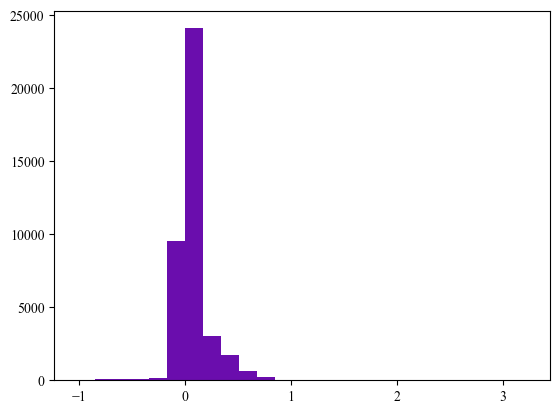

In [4089]:
from scipy.stats import wilcoxon, skew, kurtosis, lognorm, boxcox
e1 = nls_result.errors
e2 = ml_result['errors']
d = e2**2-e1**2
print(skew(d))
print(kurtosis(d))
print(skew(d))
print(kurtosis(d))
plt.hist(e2**2-e1**2,bins=25)
# plt.hist(e1,bins=17)
# plt.hist(e2,bins=17,alpha=.5)


(array([-4.14017624, -3.93201173, -3.81842742, ...,  3.81842742,
        3.93201173,  4.14017624], shape=(39946,)), array([-1.1549554 , -1.06543984, -1.05109464, ...,  3.55756893,
        3.72281103,  3.73668736], shape=(39946,)))
(np.float64(0.23747920900983283), np.float64(1.0506723377062377e-06), np.float64(0.9027781117466895))


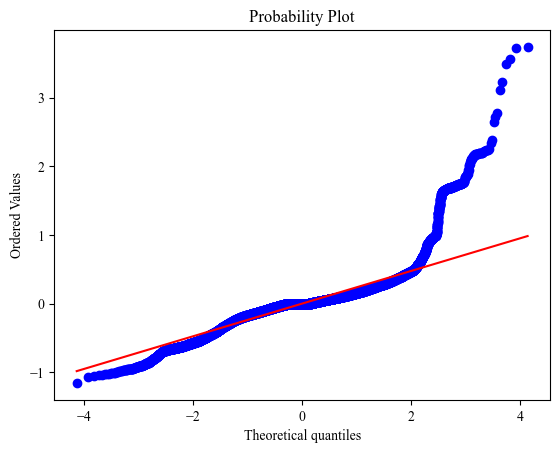

In [4066]:
from scipy.stats import probplot
foo = probplot(e1,plot=plt)
print(foo[0])
print(foo[1])
plt.show()

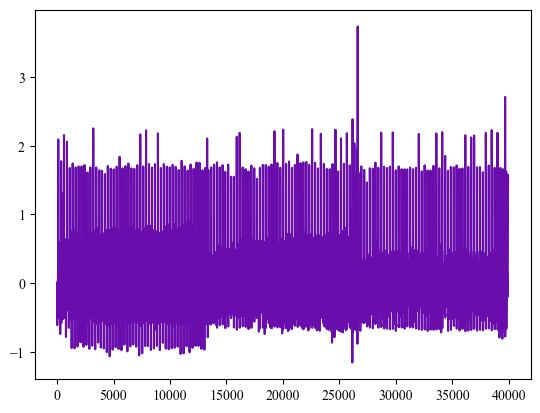

In [4067]:
plt.plot(nls_result.errors)

In [4068]:
model_comparisons = {
    'Model' : [],
    'Num Params': [],
    'Training Set' : [],
    'Test Set' : [],
    'R^2' : [],
    'RMSE' : [],
    'p-value' : []
}
from scipy.stats import wilcoxon
# compare nonlinear spring to multiple linear models (train on wiggling test on hopping)
x = nls_char_result['errors']
y = ml_char_result['errors']
pval = different_means_pvalue(np.abs(x),np.abs(y))
model_comparisons['Model'].append('Piecewise Linear')
model_comparisons['Num Params'].append(12)
model_comparisons['Training Set'].append('A')
model_comparisons['Test Set'].append('B')
model_comparisons['R^2'].append(ml_char_result['r_sqr'])
model_comparisons['RMSE'].append(np.sqrt(np.average(y**2)))
model_comparisons['p-value'].append(pval)

model_comparisons['Model'].append('Nonlinear Spring')
model_comparisons['Num Params'].append(nls_char_model.num_params())
model_comparisons['Training Set'].append('A')
model_comparisons['Test Set'].append('B')
model_comparisons['R^2'].append(nls_char_result['r_sqr'])
model_comparisons['RMSE'].append(np.sqrt(np.average(x**2)))
model_comparisons['p-value'].append(pval)

# compare nonlinear spring to multipe lienar models (train and test on hopping)
x = nls_result['errors']
y = ml_result['errors']
pval = different_means_pvalue(np.abs(x),np.abs(y))
model_comparisons['Model'].append('Piecewise Linear')
model_comparisons['Num Params'].append(12)
model_comparisons['Training Set'].append('B')
model_comparisons['Test Set'].append('B')
model_comparisons['R^2'].append(ml_result['r_sqr'])
model_comparisons['RMSE'].append(np.sqrt(np.average(y**2)))
model_comparisons['p-value'].append(pval)

model_comparisons['Model'].append('Nonlinear Spring')
model_comparisons['Num Params'].append(nls_model.num_params())
model_comparisons['Training Set'].append('B')
model_comparisons['Test Set'].append('B')
model_comparisons['R^2'].append(nls_result['r_sqr'])
model_comparisons['RMSE'].append(np.sqrt(np.average(x**2)))
model_comparisons['p-value'].append(pval)

# compare nonlinear damping to linear model (train on wiggling, test on hopping)
x = nld_char_result['errors']
y = linear_char_result['errors']
pval = different_means_pvalue(np.abs(x),np.abs(y))
model_comparisons['Model'].append('Linear')
model_comparisons['Num Params'].append(3)
model_comparisons['Training Set'].append('A')
model_comparisons['Test Set'].append('B')
model_comparisons['R^2'].append(linear_char_result['r_sqr'])
model_comparisons['RMSE'].append(np.sqrt(np.average(y**2)))
model_comparisons['p-value'].append(pval)

model_comparisons['Model'].append('Nonlinear Damper')
model_comparisons['Num Params'].append(nld_char_model.num_params())
model_comparisons['Training Set'].append('A')
model_comparisons['Test Set'].append('B')
model_comparisons['R^2'].append(nld_char_result['r_sqr'])
model_comparisons['RMSE'].append(np.sqrt(np.average(x**2)))
model_comparisons['p-value'].append(pval)

# compare nonlinear damping to linear model (train on hopping, test on hopping)
x = nld_result['errors']
y = linear_result['errors']
pval = different_means_pvalue(np.abs(x),np.abs(y))
model_comparisons['Model'].append('Linear')
model_comparisons['Num Params'].append(3)
model_comparisons['Training Set'].append('B')
model_comparisons['Test Set'].append('B')
model_comparisons['R^2'].append(linear_result['r_sqr'])
model_comparisons['RMSE'].append(np.sqrt(np.average(y**2)))
model_comparisons['p-value'].append(pval)

model_comparisons['Model'].append('Nonlinear Damper')
model_comparisons['Num Params'].append(nld_model.num_params())
model_comparisons['Training Set'].append('B')
model_comparisons['Test Set'].append('B')
model_comparisons['R^2'].append(nld_result['r_sqr'])
model_comparisons['RMSE'].append(np.sqrt(np.average(x**2)))
model_comparisons['p-value'].append(pval)

In [4069]:
model_comparisons = pd.DataFrame(model_comparisons)

In [4070]:
model_comparisons

,Model,Num Params,Training Set,Test Set,R^2,RMSE,p-value
0,Piecewise Linear,12,A,B,0.883570,0.409782,0.000000
1,Nonlinear Spring,11,A,B,0.923310,0.332574,0.000000
2,Piecewise Linear,12,B,B,0.908301,0.363666,0.000000
3,Nonlinear Spring,11,B,B,0.952031,0.263027,0.000000
4,Linear,3,A,B,0.896256,0.386813,0.077646
5,Nonlinear Damper,11,A,B,0.898947,0.381764,0.077646
6,Linear,3,B,B,0.898618,0.382384,0.279292
7,Nonlinear Damper,15,B,B,0.899995,0.379779,0.279292


0.0
0.3926990816987242
0.7853981633974484


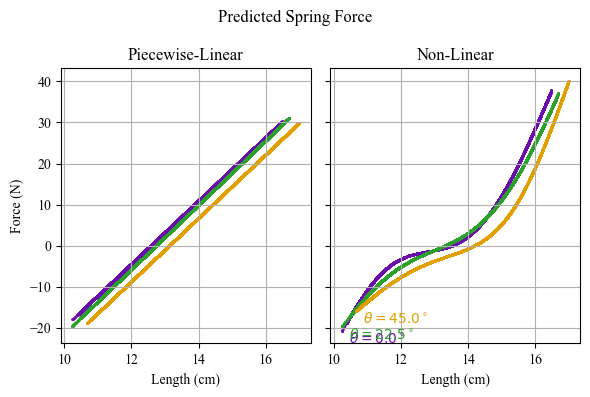

In [4071]:
# plot comparing nonlinear spring model to multiple linear spring model
fig, axs = plt.subplots(nrows=1,ncols=2,sharex=True,sharey=True, figsize=(6,4))
model = nls_model
psi_values = MODEL_TEST_DF['psi'].unique()
_linear_models = linear_models
colors = ['C0','C1','C2','C3']
for idx, psi in enumerate(psi_values):
    print(psi)
    frame = (MODEL_TEST_DF['psi'] == psi)
    df = MODEL_TEST_DF.loc[frame,:]
    l = df['l_m'].to_numpy()
    ldot = df['ldot'].to_numpy()
    lddot = df['lddot'].to_numpy()
    t = df['t_s'].to_numpy()

    model = _linear_models[idx]
    Fs = model.spring_force(l,psi)
    min_idx = np.argmin(l)
    axs[0].scatter(l*100, Fs,s=1, color=colors[idx])
    axs[0].set_title('Piecewise-Linear')
    # axs[0].annotate(rf'$\theta = {psi*180/np.pi:.1f}^\circ$', xy=(100*l[min_idx]+.4,Fs[min_idx]))
    axs[0].grid(True)
    axs[0].set_xlabel('Length (cm)')
    axs[0].set_ylabel('Force (N)')
    model = nls_model 
    Fs = model.spring_force(l,psi)
    axs[1].scatter(l*100, Fs,s=1, color=colors[idx])
    axs[1].set_title('Non-Linear')
    axs[1].grid(True)
    axs[1].set_xlabel('Length (cm)')
    axs[1].annotate(rf'$\theta = {psi*180/np.pi:.1f}^\circ$', xy=(100*l[min_idx]+.2,Fs[min_idx]-3), color=colors[idx])
fig.suptitle('Predicted Spring Force')
fig.tight_layout()

0.3926990816987242
39.95911387495329


C:\Users\Joseph\AppData\Local\Temp\ipykernel_70212\3185494324.py:35: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  print(np.trapz(ldot*(Fs+Fd),t))


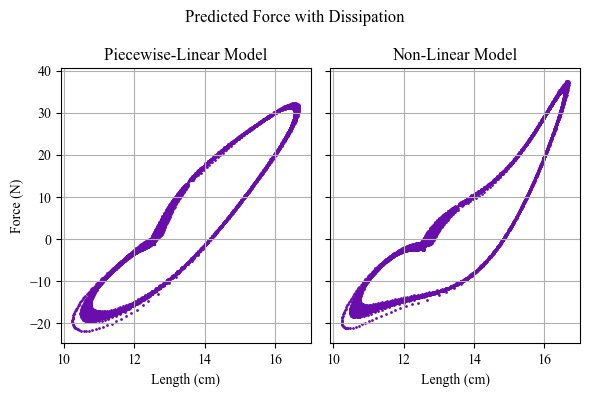

In [4072]:
from matplotlib import pyplot as plt
fig, axs = plt.subplots(nrows=1,ncols=2,sharex=True,sharey=True,figsize=(6,4))
model = nls_model
_linear_models = linear_models[1::2]
psi_values = MODEL_TEST_DF['psi'].unique()[1::2]
colors = ['C0','C2']
for idx, psi in enumerate(psi_values):
    print(psi)
    frame = (MODEL_TEST_DF['psi'] == psi)
    df = MODEL_TEST_DF.loc[frame,:]
    l = df['l_m'].to_numpy()
    ldot = df['ldot'].to_numpy()
    lddot = df['lddot'].to_numpy()
    t = df['t_s'].to_numpy()

    model = _linear_models[idx]
    Fs = model.spring_force(l,psi)
    Fd = model.dissipation_force(l,ldot,psi)

    axs[0].scatter(l*100, Fs+Fd,s=1,color=colors[idx])
    axs[0].set_title('Piecewise-Linear Model')
    axs[0].grid(True)
    axs[0].set_xlabel('Length (cm)')
    axs[0].set_ylabel('Force (N)')

    # add dashed line to separate flight mode from stance mode
    x = np.array([12,15])
    y = np.array([20,-20])

    # axs[0].plot(x,y,linestyle='-.',color='black')

    model = nls_model 
    Fs = model.spring_force(l,psi)
    Fd = model.dissipation_force(l,ldot,psi)
    print(np.trapz(ldot*(Fs+Fd),t))
    axs[1].scatter(l*100, Fs+Fd,s=1,color=colors[idx])
    axs[1].set_title('Non-Linear Model')
    axs[1].grid(True)
    axs[1].set_xlabel('Length (cm)')
    # axs[1].plot(x,y,linestyle='-.',color='black')
fig.suptitle('Predicted Force with Dissipation')
fig.tight_layout()

In [4073]:
from scipy import integrate
from hsa_hopper.kinematics import forward_kinematics
R = 1.5*.095
gear_ratio = 6
Km = (105) # 105 RPM per Volt
Kt = gear_ratio*(3/2)/np.sqrt(3)*(60/(2*np.pi))/Km # torque constant in Nm/A or Volts * seconds
energetics = {
    'HSA' : [],
    'Optimized' : [],
    'Height' : [],
    'TCOT' : [],
    'MCOT' : [],
    'COT' : [],
    'psi' : [],
}
slices = [
    MASTER_DF[(MASTER_DF['hsa'] == False) & (MASTER_DF['optimized'] == False)],
    MASTER_DF[(MASTER_DF['hsa'] == True ) & (MASTER_DF['optimized'] == False)],
    MASTER_DF[(MASTER_DF['hsa'] == False) & (MASTER_DF['optimized'] == True)],
    MASTER_DF[(MASTER_DF['hsa'] == True ) & (MASTER_DF['optimized'] == True)],
]
col_map = {col: idx for idx,col in enumerate(MASTER_DF.columns)}
for slice in slices:
    for psi in slice['psi'].unique():
        psi_mask = slice['psi'] == psi
        for hop_idx in slice.loc[psi_mask, 'hop_idx'].unique():
            idx_mask = slice['hop_idx'] == hop_idx
            frame = slice.loc[psi_mask & idx_mask,:]
            t = frame['t_s'].to_numpy()
            x = frame['x_raw'].to_numpy()
            torque = frame['torque_raw'].to_numpy()
            mode = frame['mode'].to_numpy()
            fk, jac, hess = forward_kinematics(kin_params,x,jacobian=True,hessian=True)
            xdot = np.diff(x)/ np.diff(t)
            y = fk[0]
            ydot = np.diff(y)/np.diff(t)
            l = fk[1]
            ldot = np.diff(l)/np.diff(t)

            energetics['HSA'].append(frame.iloc[0,col_map['hsa']])
            energetics['Optimized'].append(frame.iloc[0,col_map['optimized']])
            energetics['psi'].append(frame.iloc[0,col_map['psi']])

            # calculate hop height
            flight_start = next(i for i in range(len(mode)) if mode[i] == HopController._FLIGHT)
            h = ydot[flight_start]**2 / (2*9.81)
            energetics['Height'].append(h)

            # calculate thermal power and work
            power = R*(torque/Kt)**2
            TCOT = integrate.trapezoid(power,t)/(1.7*9.81*h)
            energetics['TCOT'].append(TCOT)

            # calculate motor power and work
            power = torque[1:]*xdot
            MCOT = integrate.trapezoid(power,t[1:])/(1.7*9.81*h)
            energetics['MCOT'].append(MCOT)

            # calculate total electrical loss
            energetics['COT'].append(TCOT+MCOT)
energetics = pd.DataFrame(energetics)

# drop outlier rows by hop height
height_filter = (energetics['Height'] > .04) & (energetics['Height']<.07)
energetics = energetics[height_filter]

# drop psi = 67.5 degrees (hop heights come from a different distribution)
psi_filter = (energetics['HSA'] == True) & (energetics['Optimized'] == True) & (energetics['psi'] == energetics['psi'].max())
energetics = energetics[~ psi_filter]

(array([ 2.,  3., 17., 16., 13., 25.,  7., 10.,  5.,  3.]),
 array([1.77166112, 1.81792216, 1.86418321, 1.91044425, 1.9567053 ,
        2.00296635, 2.04922739, 2.09548844, 2.14174948, 2.18801053,
        2.23427158]),
 <BarContainer object of 10 artists>)

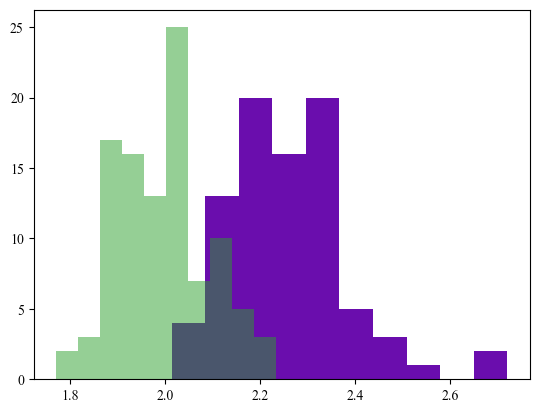

In [4074]:
hsa_opt_slice = (energetics['HSA'] == True) & (energetics['Optimized'] == True)
hsa_nopt_slice = (energetics['HSA'] == True) & (energetics['Optimized'] == False)
x = energetics.loc[hsa_nopt_slice,'COT']
y = energetics.loc[hsa_opt_slice,'COT']

plt.hist(x)
plt.hist(y,alpha=.5)

WilcoxonResult(statistic=np.float64(50005000.0), pvalue=np.float64(0.0))
0.12015281411053667
0.009114858362915776


(array([  14.,   83.,  550., 1665., 2847., 2767., 1492.,  492.,   86.,
           4.]),
 array([1.96152481, 1.9686896 , 1.97585439, 1.98301918, 1.99018398,
        1.99734877, 2.00451356, 2.01167835, 2.01884314, 2.02600794,
        2.03317273]),
 <BarContainer object of 10 artists>)

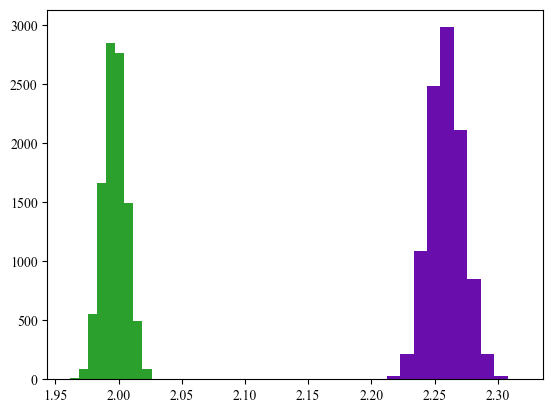

In [4075]:
# bootstrapping stats for comparison
from numpy.random import default_rng
from scipy.stats import wilcoxon, skewtest, kurtosistest, skew
rng = default_rng(seed=42)
def bootstrap(arr: np.ndarray, N_iters):
    N_rows = arr.size
    sample_means = np.zeros(N_iters)
    for i in range(N_iters):
        sample = arr[np.random.choice(N_rows,N_rows,replace=True)]
        sample_means[i] = np.average(sample)
    return sample_means
x_sample_means = bootstrap(x.to_numpy(),int(1e4))
y_sample_means = bootstrap(y.to_numpy(),int(1e4))
print(wilcoxon(x_sample_means-y_sample_means, alternative='greater'))
print(skew(x_sample_means))
print(skew(y_sample_means))
# print(goodness_of_fit(tdist,x_sample_means-y_sample_means))
plt.hist(x_sample_means)
plt.hist(y_sample_means)

KurtosistestResult(statistic=np.float64(0.7027977390450204), pvalue=np.float64(0.4821818064463377))


(array([  5.,  17.,  82., 175., 273., 248., 134.,  57.,   5.,   4.]),
 array([-3.31783989, -2.63128066, -1.94472143, -1.25816221, -0.57160298,
         0.11495625,  0.80151547,  1.4880747 ,  2.17463393,  2.86119316,
         3.54775238]),
 <BarContainer object of 10 artists>)

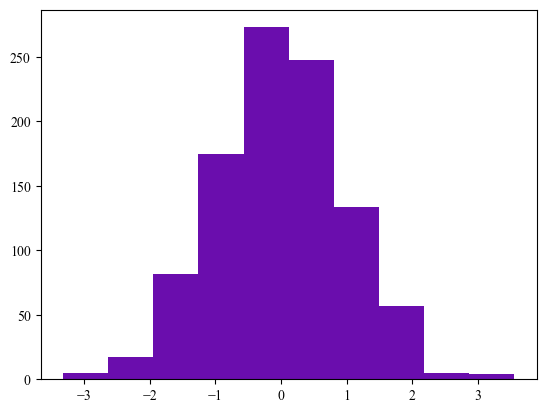

In [4076]:
foo = np.random.normal(0,1,1000)
print(kurtosistest(foo))
plt.hist(foo)